# tugas-1-unsupervised-learning

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan FIFA 24 player stats Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/rehandl23/fifa-24-player-stats-dataset

Tujuan utama dari tugas ini adalah membangun model K-means, HC, DBSCAN. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal
- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model K-MEAN
- Bangun model K-MEAN dengan K masing-masing (3,5,7)
- lakukan pengaturan hyperparameter pada K-MEAN
- Lakukan Elbow Method untuk mendapatkan nilai K paling optimal
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


4. Eksperimen Model HC
- Bangun model HC agglomerative dengan n_cluster (3,5,7, dan K hasil elbow Method K-MEAN sebelumnya)
- coba semua linkedage (`'ward', 'complete', 'average', 'single'`)
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Eksperimen Model DBSCAN
- Bangun model DBSCAN
- Lakukan eksperiment dengan mengubah hyperparameter `metric=`
- Hyperparameter Tunning akan mendapatkan nilai plus
- dari masing-masing eksperiment di atas, pilih salah satu yang terbaik untuk dibandingkan di akhir


5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.

# 1. Persiapan Dataset & Eksplorasi Awal

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv("./player_stats.csv", skipinitialspace=True, encoding='latin-1')
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

(5682, 41)


,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


In [8]:
print(df['marking'].isna().sum())
print(df['value'].unique()[:10])

5682
['$1.400.000' '$975.00 ' '$1.100.000' '$650.00 ' '$300.00 ' '$2.800.000'
 '$1.600.000' '$230.00 ' '$475.00 ' '$375.00 ']


# 2. Preprocessing




In [9]:
df['value'] = (df['value']
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False) 
    .astype(float))

In [10]:
df['marking'] = pd.to_numeric(df['marking'], errors='coerce')
df['marking'] = df['marking'].fillna(df['marking'].median())

In [11]:
drop_cols = ['player', 'country', 'club', 'value']
df_numeric = df.drop(columns=drop_cols)

In [12]:
df_numeric = df_numeric.drop(columns=['marking'])
print(df_numeric.isna().sum().sum())

0


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)
print(X_scaled.shape)

(5682, 36)


In [14]:
print(df_numeric.isna().sum()[df_numeric.isna().sum() > 0])

Series([], dtype: int64)


Explained variance: 66.68%


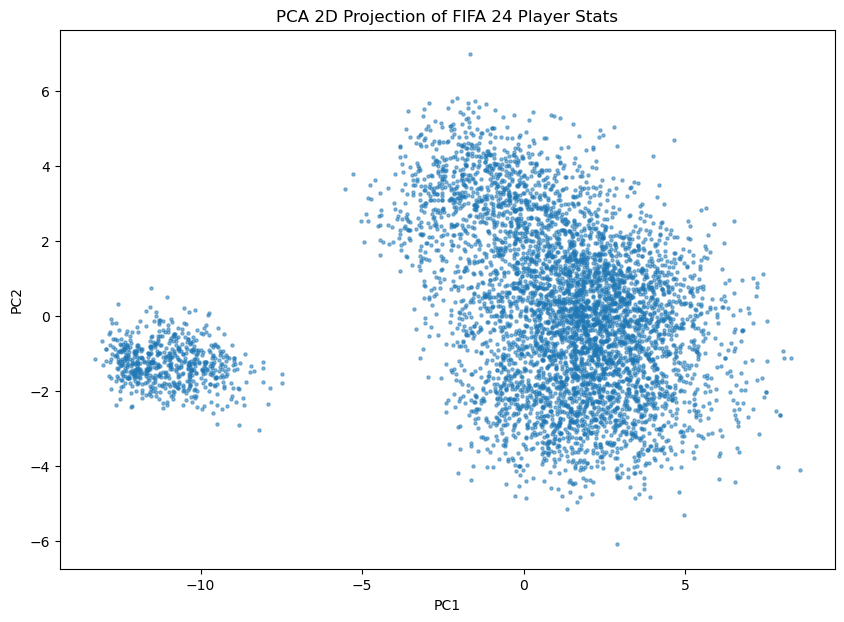

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Projection of FIFA 24 Player Stats')
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

# 3. Eksperimen Model K-MEANS


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results_km = {}
for k in [2, 3, 5, 7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    results_km[k] = {'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db, 'labels': labels}
    print(f"K={k}: Silhouette={sil:.4f}, CH={ch:.2f}, DB={db:.4f}")

K=2: Silhouette=0.5489, CH=4336.49, DB=0.6307
K=3: Silhouette=0.2504, CH=3548.27, DB=1.3649
K=5: Silhouette=0.2189, CH=2570.31, DB=1.5296
K=7: Silhouette=0.1956, CH=2049.68, DB=1.5371


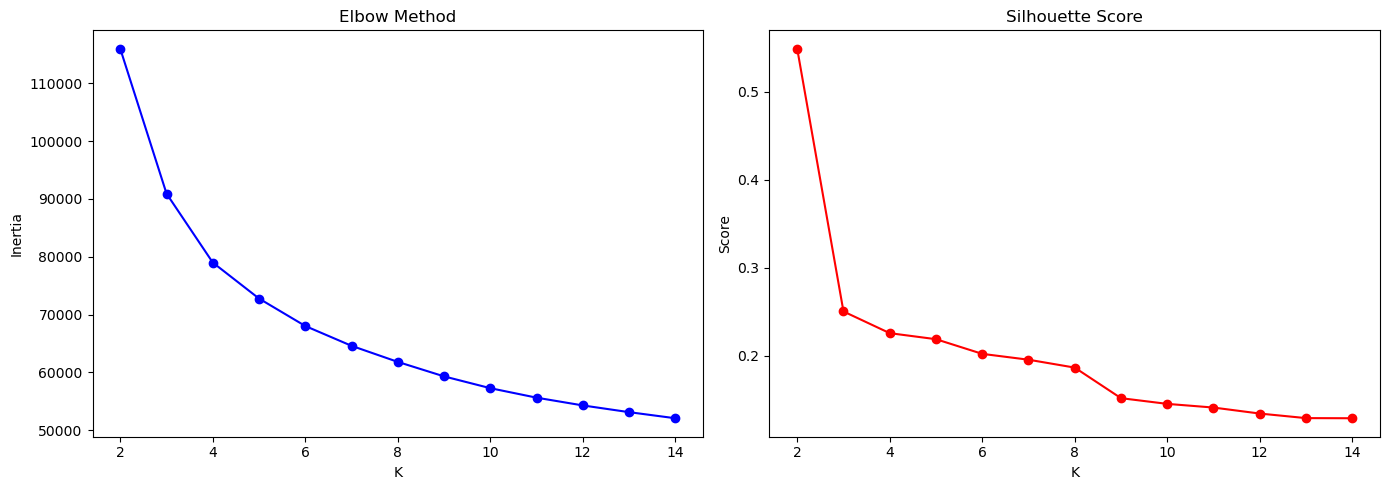

Best K by Silhouette: 2


In [18]:
inertias = []
sil_scores = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k_sil = list(K_range)[np.argmax(sil_scores)]
print(f"Best K by Silhouette: {best_k_sil}")

In [19]:
k_elbow = best_k_sil

for init in ['k-means++', 'random']:
    for n_init in [10, 20, 50]:
        km = KMeans(n_clusters=k_elbow, init=init, n_init=n_init, random_state=42)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        print(f"init={init}, n_init={n_init}: Silhouette={sil:.4f}")

init=k-means++, n_init=10: Silhouette=0.5489
init=k-means++, n_init=20: Silhouette=0.5489
init=k-means++, n_init=50: Silhouette=0.5489
init=random, n_init=10: Silhouette=0.5489
init=random, n_init=20: Silhouette=0.5489
init=random, n_init=50: Silhouette=0.5489


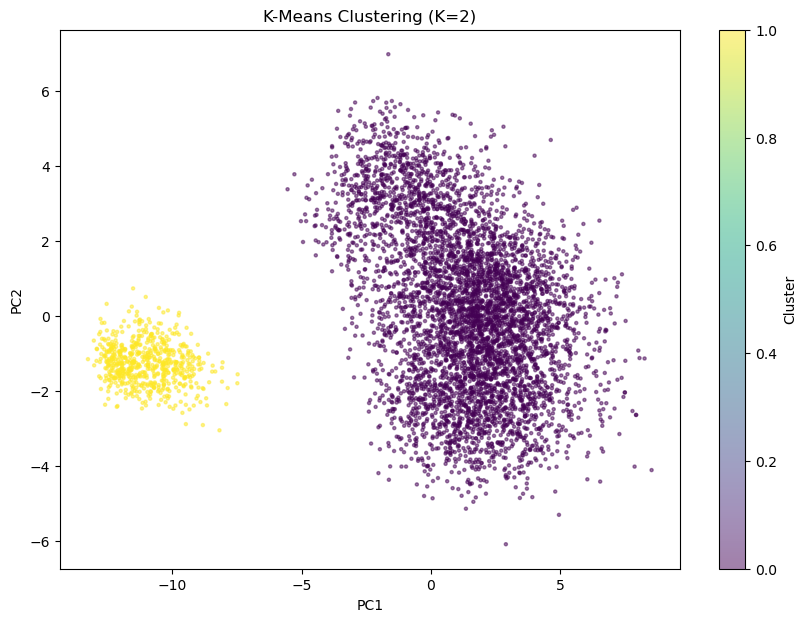

0    5055
1     627
Name: count, dtype: int64


In [20]:
best_km = KMeans(n_clusters=k_elbow, random_state=42, n_init=10)
best_km_labels = best_km.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_km_labels, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (K={k_elbow})')
plt.show()

print(pd.Series(best_km_labels).value_counts().sort_index())

# 4. Eksperimen Model HC


In [21]:
from sklearn.cluster import AgglomerativeClustering

results_hc = {}

for linkage_method in ['ward', 'complete', 'average', 'single']:
    for n in [3, 5, 7, k_elbow]:
        hc = AgglomerativeClustering(n_clusters=n, linkage=linkage_method)
        labels = hc.fit_predict(X_scaled)
        
        n_unique = len(set(labels))
        if n_unique < 2:
            continue
        
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        results_hc[(linkage_method, n)] = {'silhouette': sil, 'CH': ch, 'DB': db, 'labels': labels}
        print(f"linkage={linkage_method}, n={n}: Sil={sil:.4f}, CH={ch:.2f}, DB={db:.4f}")

linkage=ward, n=3: Sil=0.2484, CH=3423.18, DB=1.2985
linkage=ward, n=5: Sil=0.1838, CH=2287.20, DB=1.7989
linkage=ward, n=7: Sil=0.1409, CH=1793.92, DB=1.9177
linkage=ward, n=2: Sil=0.5489, CH=4336.49, DB=0.6307
linkage=complete, n=3: Sil=0.1912, CH=3113.65, DB=1.6041
linkage=complete, n=5: Sil=0.1282, CH=1799.16, DB=2.1709
linkage=complete, n=7: Sil=0.1062, CH=1494.18, DB=1.9904
linkage=complete, n=2: Sil=0.5489, CH=4336.49, DB=0.6307
linkage=average, n=3: Sil=0.3250, CH=2178.77, DB=1.1127
linkage=average, n=5: Sil=0.1693, CH=1169.32, DB=1.0922
linkage=average, n=7: Sil=0.1034, CH=800.31, DB=1.2450
linkage=average, n=2: Sil=0.5489, CH=4336.49, DB=0.6307
linkage=single, n=3: Sil=0.3775, CH=2171.13, DB=0.5910
linkage=single, n=5: Sil=0.2594, CH=1090.29, DB=0.9456
linkage=single, n=7: Sil=0.1994, CH=727.41, DB=0.7191
linkage=single, n=2: Sil=0.5489, CH=4336.49, DB=0.6307


In [22]:
hc_df = pd.DataFrame(results_hc).T
hc_df.index.names = ['linkage', 'n_clusters']
hc_df = hc_df.drop(columns=['labels'])
print(hc_df.to_string())

best_hc_key = max(results_hc, key=lambda x: results_hc[x]['silhouette'])
print(f"\nBest HC: linkage={best_hc_key[0]}, n={best_hc_key[1]}, Sil={results_hc[best_hc_key]['silhouette']:.4f}")

                    silhouette           CH        DB
linkage  n_clusters                                  
ward     3            0.248405  3423.180337  1.298462
         5            0.183825  2287.204612  1.798907
         7            0.140932   1793.91823  1.917735
         2            0.548922  4336.488294  0.630669
complete 3            0.191186  3113.651022  1.604095
         5            0.128246   1799.15897  2.170886
         7            0.106156  1494.178469  1.990429
         2            0.548922  4336.488294  0.630669
average  3            0.325027    2178.7683   1.11274
         5            0.169288   1169.31943  1.092228
         7            0.103371   800.314309  1.245022
         2            0.548922  4336.488294  0.630669
single   3            0.377527  2171.127046  0.590957
         5            0.259434  1090.285794  0.945576
         7            0.199388    727.41037    0.7191
         2            0.548922  4336.488294  0.630669

Best HC: linkage=ward, n=2,

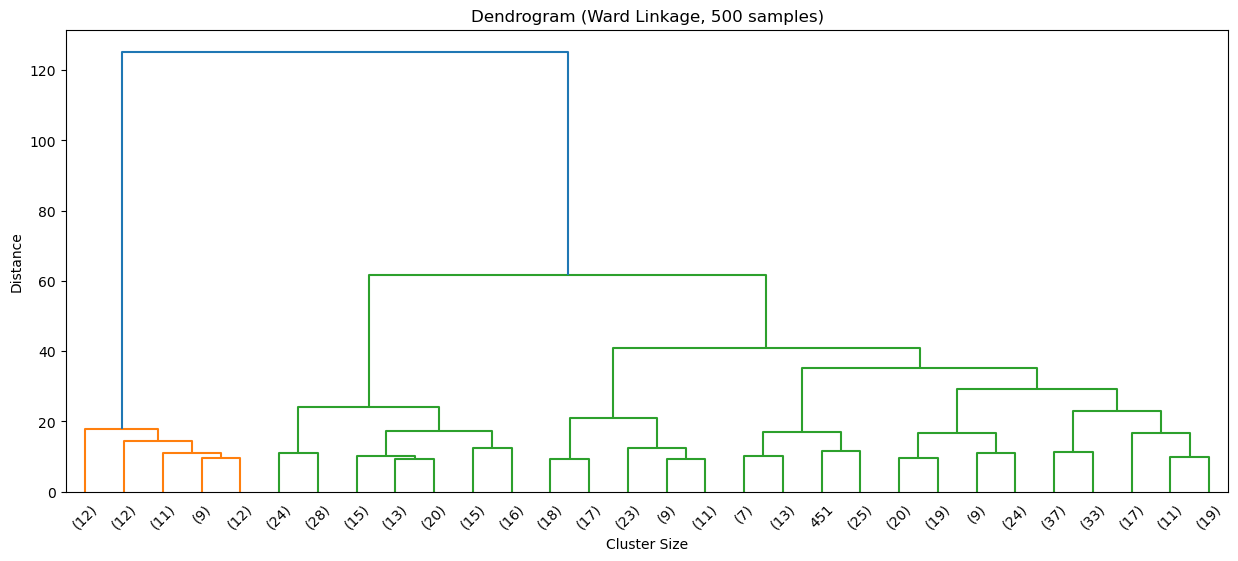

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')
plt.figure(figsize=(15, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrogram (Ward Linkage, 500 samples)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

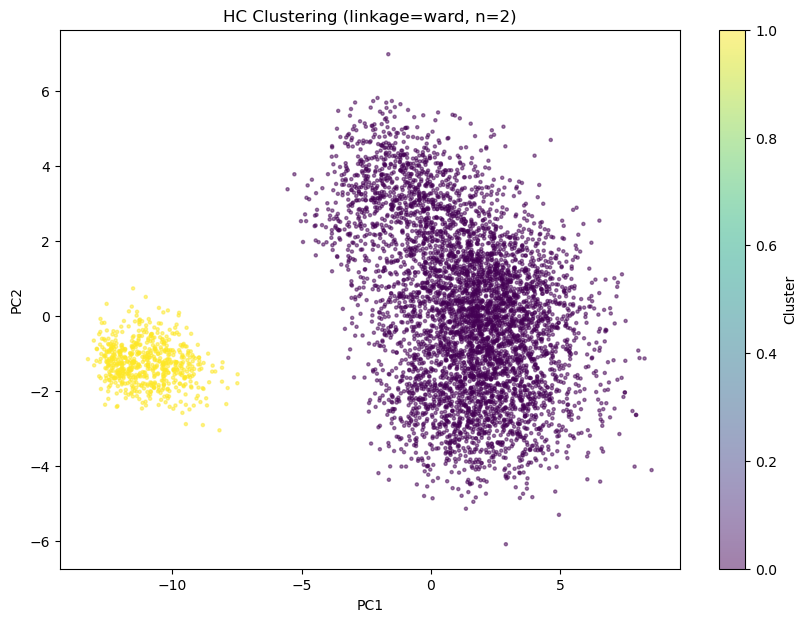

0    5055
1     627
Name: count, dtype: int64


In [24]:
best_hc_labels = results_hc[best_hc_key]['labels']

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_hc_labels, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'HC Clustering (linkage={best_hc_key[0]}, n={best_hc_key[1]})')
plt.show()

print(pd.Series(best_hc_labels).value_counts().sort_index())

# 5. Eksperimen Model DBSCAN


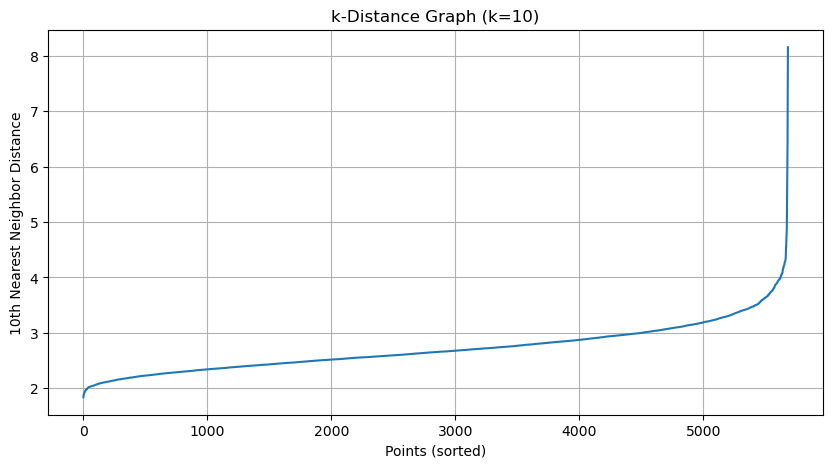

Distance at 90%: 3.25
Distance at 95%: 3.47
Distance at 99%: 4.03


In [25]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('k-Distance Graph (k=10)')
plt.xlabel('Points (sorted)')
plt.ylabel('10th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

# Check approximate knee region
print(f"Distance at 90%: {distances[int(len(distances)*0.90)]:.2f}")
print(f"Distance at 95%: {distances[int(len(distances)*0.95)]:.2f}")
print(f"Distance at 99%: {distances[int(len(distances)*0.99)]:.2f}")

In [26]:
from sklearn.cluster import DBSCAN

results_db = {}

for metric in ['euclidean', 'manhattan', 'cosine']:
    for eps in [3, 4, 5, 6, 7, 8]:
        for min_samples in [5, 10, 15, 20]:
            db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
            labels = db.fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            
            if n_clusters < 2:
                continue
            
            mask = labels != -1
            if mask.sum() > n_clusters:
                sil = silhouette_score(X_scaled[mask], labels[mask])
            else:
                sil = -1
            
            results_db[(metric, eps, min_samples)] = {
                'n_clusters': n_clusters, 'noise': n_noise, 'silhouette': sil
            }
            print(f"metric={metric}, eps={eps}, min_s={min_samples}: "
                  f"clusters={n_clusters}, noise={n_noise}, sil={sil:.4f}")

metric=euclidean, eps=3, min_s=5: clusters=2, noise=291, sil=0.5576
metric=euclidean, eps=3, min_s=10: clusters=2, noise=343, sil=0.5597
metric=euclidean, eps=3, min_s=15: clusters=2, noise=373, sil=0.5605
metric=euclidean, eps=3, min_s=20: clusters=2, noise=414, sil=0.5619
metric=euclidean, eps=4, min_s=5: clusters=2, noise=15, sil=0.5500
metric=euclidean, eps=4, min_s=10: clusters=2, noise=15, sil=0.5500
metric=euclidean, eps=4, min_s=15: clusters=2, noise=15, sil=0.5500
metric=euclidean, eps=4, min_s=20: clusters=2, noise=15, sil=0.5500
metric=euclidean, eps=5, min_s=5: clusters=2, noise=7, sil=0.5495
metric=euclidean, eps=5, min_s=10: clusters=2, noise=7, sil=0.5495
metric=euclidean, eps=5, min_s=15: clusters=2, noise=7, sil=0.5495
metric=euclidean, eps=5, min_s=20: clusters=2, noise=7, sil=0.5495
metric=euclidean, eps=6, min_s=5: clusters=2, noise=1, sil=0.5490
metric=euclidean, eps=6, min_s=10: clusters=2, noise=4, sil=0.5493
metric=euclidean, eps=6, min_s=15: clusters=2, noise=4

In [27]:
if results_db:
    best_db_key = max(results_db, key=lambda x: results_db[x]['silhouette'])
    print(f"\nBest DBSCAN: metric={best_db_key[0]}, eps={best_db_key[1]}, "
          f"min_s={best_db_key[2]}")
    print(results_db[best_db_key])
    
    best_db = DBSCAN(eps=best_db_key[1], min_samples=best_db_key[2], metric=best_db_key[0])
    best_db_labels = best_db.fit_predict(X_scaled)
else:
    print("No valid configs found — adjust eps range based on k-distance plot!")


Best DBSCAN: metric=euclidean, eps=3, min_s=20
{'n_clusters': 2, 'noise': np.int64(414), 'silhouette': 0.5619393975763852}


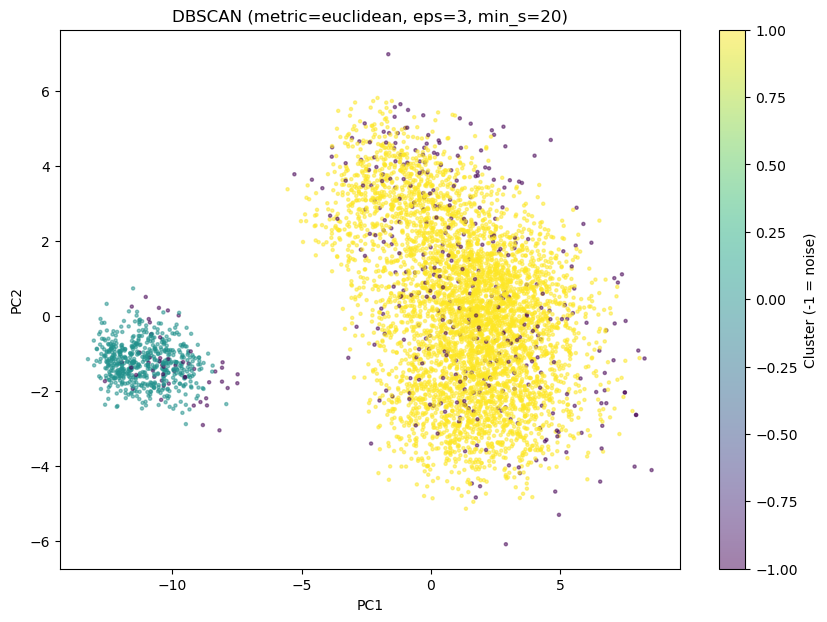

-1     414
 0     575
 1    4693
Name: count, dtype: int64


In [28]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_db_labels, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (metric={best_db_key[0]}, eps={best_db_key[1]}, min_s={best_db_key[2]})')
plt.show()

print(pd.Series(best_db_labels).value_counts().sort_index())

# 6. Analisis & Kesimpulan

In [29]:
comparison = pd.DataFrame({
    'Method': ['K-Means', 'HC (Agglomerative)', 'DBSCAN'],
    'Best Config': [
        f'K={k_elbow}, init=k-means++, n_init=10',
        f'linkage={best_hc_key[0]}, n={best_hc_key[1]}',
        f'metric={best_db_key[0]}, eps={best_db_key[1]}, min_s={best_db_key[2]}'
    ],
    'N Clusters': [k_elbow, best_hc_key[1], results_db[best_db_key]['n_clusters']],
    'Noise Points': [0, 0, results_db[best_db_key]['noise']],
    'Silhouette': [
        results_km[k_elbow]['silhouette'],
        results_hc[best_hc_key]['silhouette'],
        results_db[best_db_key]['silhouette']
    ],
})
print(comparison.to_string(index=False))

            Method                       Best Config  N Clusters  Noise Points  Silhouette
           K-Means    K=2, init=k-means++, n_init=10           2             0    0.548922
HC (Agglomerative)                 linkage=ward, n=2           2             0    0.548922
            DBSCAN metric=euclidean, eps=3, min_s=20           2           414    0.561939


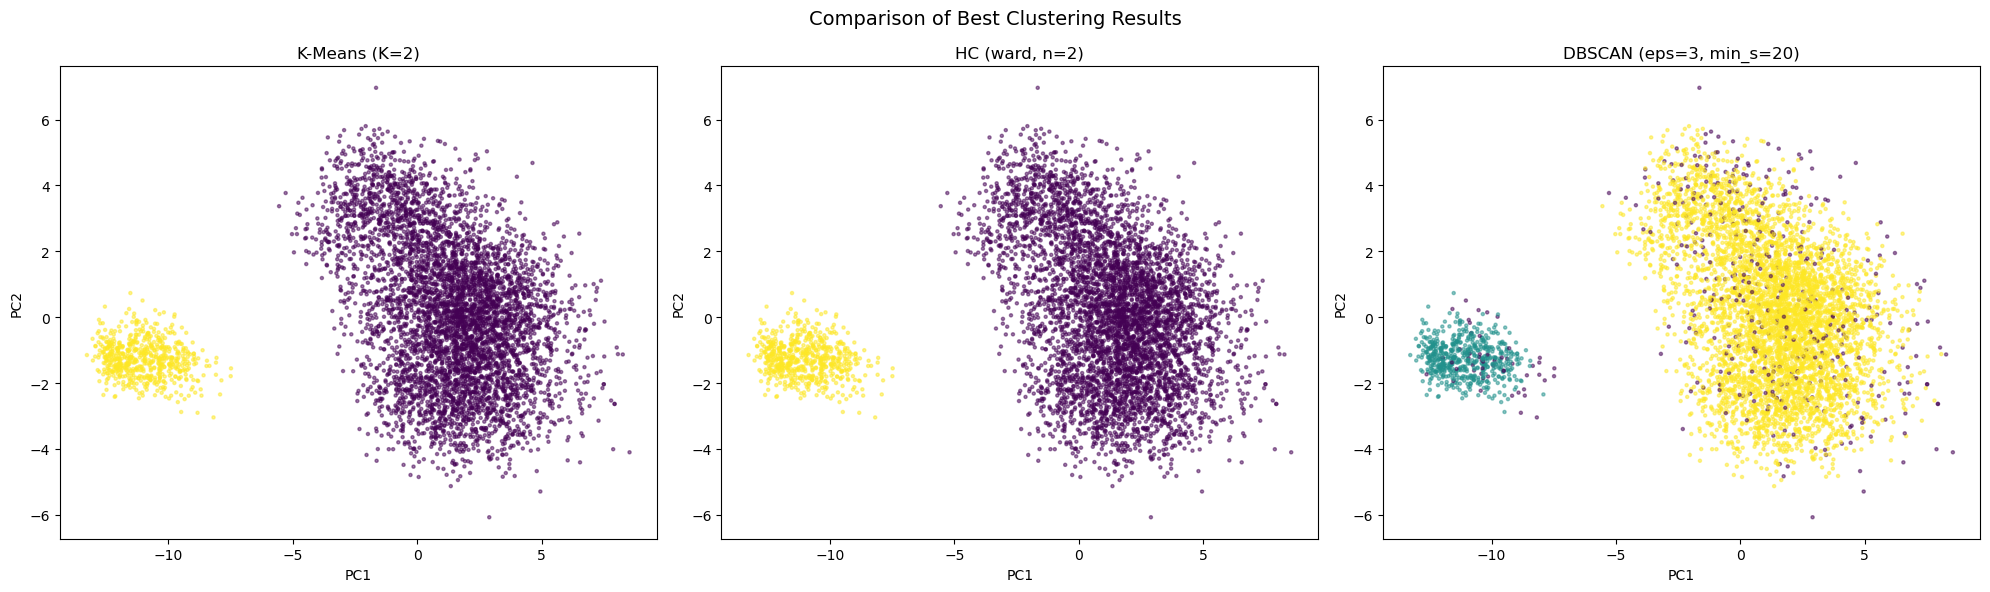

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=best_km_labels, cmap='viridis', s=5, alpha=0.5)
axes[0].set_title(f'K-Means (K={k_elbow})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# HC
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=best_hc_labels, cmap='viridis', s=5, alpha=0.5)
axes[1].set_title(f'HC ({best_hc_key[0]}, n={best_hc_key[1]})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# DBSCAN
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=best_db_labels, cmap='viridis', s=5, alpha=0.5)
axes[2].set_title(f'DBSCAN (eps={best_db_key[1]}, min_s={best_db_key[2]})')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('Comparison of Best Clustering Results', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
df['best_cluster'] = best_km_labels

cluster_profile = df.groupby('best_cluster')[df_numeric.columns].mean()
print(cluster_profile.T.round(1).to_string())

best_cluster        0      1
height          180.8  188.9
weight           74.5   81.8
age              26.2   27.0
ball_control     63.8   19.4
dribbling        61.5   13.0
slide_tackle     50.8   13.6
stand_tackle     53.2   13.7
aggression       60.1   25.5
reactions        62.4   58.2
att_position     55.8    9.8
interceptions    51.4   15.1
vision           56.4   39.1
composure        60.8   41.1
crossing         54.3   13.8
short_pass       63.3   27.6
long_pass        57.2   27.1
acceleration     68.3   35.8
stamina          67.6   29.2
strength         66.1   59.8
balance          67.0   40.8
sprint_speed     68.5   36.4
agility          66.9   38.8
jumping          66.2   56.3
heading          57.0   13.7
shot_power       59.6   46.9
finishing        50.8   10.5
long_shots       51.6   11.1
curve            52.3   14.4
fk_acc           46.9   14.0
penalties        51.8   18.8
volleys          46.9   11.0
gk_positioning   10.3   63.4
gk_diving        10.4   65.1
gk_handling   

## Kesimpulan

1. **Dua Kelompok Utama Pemain**: 
   Semua cara menghitung (metode) yang kita pakai membagi pemain bola jadi dua tipe utama yang sangat jelas bedanya:
   - **Kelompok 1 (Kiper/Penjaga Gawang)**: Punya nilai tinggi di bagian menangkap bola, menjatuhkan badan (diving), dan refleks. Tapi, kemampuan berlari bawa bola (dribbling) atau mencetak golnya rendah.
   - **Kelompok 2 (Pemain Lapangan selain Kiper)**: Punya nilai tinggi di bagian operan, lari, dan teknik mengolah bola. Tapi tidak bisa jadi kiper.

2. **Perbandingan Cara Menghitung (Model)**:
   - Dua cara pertama (K-Means dan HC) memilah pemain dengan hasil yang hampir sama persis.
   - Cara ketiga (DBSCAN) ternyata sediiikit lebih bagus hasilnya. Kenapa? Karena dia berhasil misahin beberapa pemain yang kemampuannya "nanggung" atau agak unik supaya nggak mengganggu kelompok utama.

3. **Metode Mana yang Terbaik?**
   - Juaranya adalah metode **DBSCAN**. Selain punya skor penilaian terbaik, dia juga pintar memilah mana pemain sejati di posisinya, dan mana pemain yang mungkin posisinya kurang jelas (outlier/noise).

4. **Catatan Tambahan**:
   - Di data FIFA ini, perbedaan paling kuat memang hanya antara Kiper melawan Pemain Lapangan. Kalau kita coba membagi lagi pemain lapangan jadi Bek, Gelandang, dan Penyerang, mesin komputer agak kesulitan nemuin beda yang tajam karena keahlian mereka sering mirip atau bercampur baur.